In [60]:
import re
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

In [61]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [62]:
corpus = """
    I love machine learning.
    I love deep learning.
    Machine learning is interesting.
    Deep learning is powerful.
    Machine learning uses data.
    Deep learning uses neural networks.
    """

In [63]:
def tokenize(text):

    text = text.lower()

    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text.split()

In [64]:
tokens = tokenize(corpus)
tokens[:10]

['i',
 'love',
 'machine',
 'learning',
 'i',
 'love',
 'deep',
 'learning',
 'machine',
 'learning']

In [65]:
vocab = sorted(set(tokens))
len(vocab)

12

In [66]:
word_to_id = {word: i for i, word in enumerate(vocab)}
id_to_word = {i: word for word, i in word_to_id.items()}

for word, idx in word_to_id.items():
    print(f"{word}: {idx}")

data: 0
deep: 1
i: 2
interesting: 3
is: 4
learning: 5
love: 6
machine: 7
networks: 8
neural: 9
powerful: 10
uses: 11


In [67]:
encoded_tokens = [word_to_id[word] for word in tokens]
encoded_tokens

[2, 6, 7, 5, 2, 6, 1, 5, 7, 5, 4, 3, 1, 5, 4, 10, 7, 5, 11, 0, 1, 5, 11, 9, 8]

In [68]:
window_size = 2
def create_skipgram_pairs(tokens, window_size=2):
    pairs = []

    for i, target in enumerate(tokens):
        start = max(0, i-window_size)
        end = min(len(tokens), i+window_size+1)

        for j in range(start, end):
            if i==j:
                continue

            context = tokens[j]
            pairs.append((target, context))

    return pairs


In [69]:
pairs = create_skipgram_pairs(encoded_tokens, window_size=2)
pairs[:10]

[(2, 6),
 (2, 7),
 (6, 2),
 (6, 7),
 (6, 5),
 (7, 2),
 (7, 6),
 (7, 5),
 (7, 2),
 (5, 6)]

In [70]:
class SkipGramDataset(Dataset):

    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        traget, context = self.pairs[index]
        return (torch.tensor(traget, dtype=torch.long), torch.tensor(context, dtype=torch.long))

In [71]:
dataset = SkipGramDataset(pairs)
dataloader = DataLoader(dataset, batch_size=4, shuffle=False)
len(dataloader)

24

In [72]:
encoded_tokens

[2, 6, 7, 5, 2, 6, 1, 5, 7, 5, 4, 3, 1, 5, 4, 10, 7, 5, 11, 0, 1, 5, 11, 9, 8]

In [73]:
class SkipGram(nn.Module):

    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.linear = nn.Linear(embedding_dim, vocab_size)

    def forward(self, traget):
        embedding = self.embedding(traget)
        output = self.linear(embedding)
        return output

In [76]:
embedding_dim = 50
vocab_size = len(dataset)

model = SkipGram(vocab_size=vocab_size, embedding_dim=embedding_dim).to(device)

In [77]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [78]:
epochs = 100

loss_history = []

for epoch in range(epochs):

    total_loss = 0

    for target, context in dataloader:

        target = target.to(device)
        context = context.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        output = model(target)

        # Calculate loss
        loss = criterion(
            output,
            context
        )

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        total_loss += loss.item()

    average_loss = (
        total_loss /
        len(dataloader)
    )

    loss_history.append(
        average_loss
    )

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch {epoch + 1:03d} | "
            f"Loss: {average_loss:.4f}"
        )

Epoch 010 | Loss: 1.8739
Epoch 020 | Loss: 1.8443
Epoch 030 | Loss: 1.8270
Epoch 040 | Loss: 1.8272
Epoch 050 | Loss: 1.8131
Epoch 060 | Loss: 1.8082
Epoch 070 | Loss: 1.8014
Epoch 080 | Loss: 1.7972
Epoch 090 | Loss: 1.7909
Epoch 100 | Loss: 1.7882


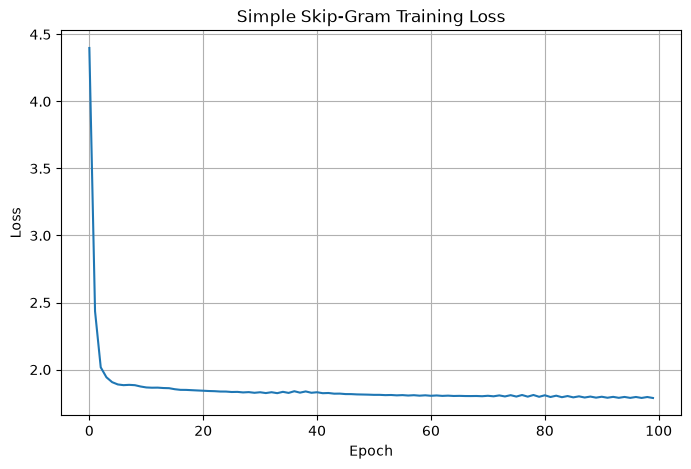

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Simple Skip-Gram Training Loss"
)

plt.grid()

plt.show()

In [80]:
model.embedding.weight

Parameter containing:
tensor([[ 0.6056,  0.9937,  0.2075,  ...,  0.4127,  0.3177, -1.8445],
        [-2.0667, -0.0606,  0.1290,  ..., -0.3824,  0.1811, -0.2216],
        [-1.5349,  0.5126, -1.3903,  ..., -1.4896, -0.5980, -1.8709],
        ...,
        [-1.4343, -1.0288,  2.1875,  ..., -0.2272, -0.2354, -1.0285],
        [-0.4470, -0.8202,  0.7264,  ..., -0.1599, -0.0999, -0.1588],
        [-0.0503, -0.3604,  1.9071,  ..., -1.2435, -0.7312, -0.3858]],
       requires_grad=True)

In [81]:
embeddings = (
    model.embedding.weight
    .detach()
    .cpu()
)

print(
    "Embedding shape:",
    embeddings.shape
)

Embedding shape: torch.Size([94, 50])


In [82]:
word = "machine"

word_id = word_to_id[word]

vector = embeddings[word_id]

print("Word:", word)
print("ID:", word_id)

print("\nVector:")
print(vector)

print(
    "\nVector shape:",
    vector.shape
)

Word: machine
ID: 7

Vector:
tensor([ 0.2111, -0.9119, -0.2505, -0.3164, -1.0302, -1.4968, -1.5000,  0.5033,
        -0.2164,  0.4594, -1.0738,  1.0179,  0.8817,  0.3232,  1.3596, -0.3943,
         0.4493, -1.3344,  0.1244,  0.3297,  0.5841, -0.1976,  0.7837, -0.0938,
        -1.2849,  0.0961,  0.6908, -0.2190,  0.3824,  0.1026,  0.3092,  1.4218,
        -0.0762, -0.2694, -2.0956,  1.0097, -1.1558, -0.4010,  0.1011,  0.0795,
        -0.0765, -0.1695,  0.8895, -0.2859, -0.3732, -0.2480,  0.8818, -1.7182,
        -0.4771, -1.0587])

Vector shape: torch.Size([50])


In [83]:
import torch.nn.functional as F


def similarity(
    word1,
    word2
):

    id1 = word_to_id[word1]
    id2 = word_to_id[word2]

    vector1 = embeddings[id1]
    vector2 = embeddings[id2]

    score = F.cosine_similarity(
        vector1.unsqueeze(0),
        vector2.unsqueeze(0)
    )

    return score.item()